#### Description:

In [101]:
'''
    I aim to Build a Model That Predicat the salary based on:
        (city, occupation, field, years_of_experience, employment_type, education_level, gender, company_size)
'''

'\n    I aim to Build a Model That Predicat the salary based on:\n        (city, occupation, field, years_of_experience, employment_type, education_level, gender, company_size)\n'

#### Import Data and Select Features

In [111]:
# Import Packages
import pandas as pd

In [112]:
# from google.colab import drive
# drive.mount('/content/drive')
# %ls drive/MyDrive/job_market_dataset.csv

data = pd.read_csv("drive/MyDrive/job_market_dataset.csv")
# data = pd.read_csv("./data/job_market_dataset.csv")
data.head(2)

,country,city,occupation,field,years_of_experience,salary,employment_type,education_level,gender,company_size,year,month
0,Switzerland,Zurich,Operations Manager,Operations,16,359609.0,work_from_home,Master,Male,Large,2023,8
1,India,Bangalore,HR Analyst,Human Resources,12,79059.0,part_time,PhD,Male,Large,2023,5


In [113]:
# Delete Features (year, month)
cp_data = data.drop(["year", "month"], axis=1)
cp_data = cp_data.iloc[:100000] # take just 100K
cp_data.head(4)

,country,city,occupation,field,years_of_experience,salary,employment_type,education_level,gender,company_size
0,Switzerland,Zurich,Operations Manager,Operations,16,359609.0,work_from_home,Master,Male,Large
1,India,Bangalore,HR Analyst,Human Resources,12,79059.0,part_time,PhD,Male,Large
2,Sweden,Stockholm,Software Engineer,Technology,10,258077.0,freelance,Master,Male,Enterprise
3,South Korea,Seoul,Operations Manager,Operations,7,252282.0,part_time,Master,Female,Large


#### Feature Encoding 

In [114]:
from sklearn.preprocessing import LabelEncoder # for Mapping / Label Encoder
from sklearn.preprocessing import OneHotEncoder # for One Hot Encoding

In [115]:
# Mapping/Label Encoding This Varaibles
company_size_map = {'Large': 3, 'Enterprise': 2, 'Medium': 1, 'Small': 0}
cp_data["company_size"] = [company_size_map[v] for v in cp_data["company_size"]]

gender_map = {'Male': 0, 'Female': 1, 'Other': 2}
cp_data["gender"] = [gender_map[v] for v in cp_data["gender"]]

education_level_map = {'PhD': 3, 'Master': 2, 'Bachelor': 1, 'High School': 0}
cp_data["education_level"] = [education_level_map[v] for v in cp_data["education_level"]]

# One-Hot-Encoding
one_hot_encoder = OneHotEncoder()
cp_data = pd.get_dummies(cp_data, columns=["field", "employment_type", "city", "country", "occupation"])
cp_data.head(3)

,years_of_experience,salary,education_level,gender,company_size,field_Business,field_Design,field_Finance,field_Human Resources,field_Marketing,...,occupation_Cloud Engineer,occupation_Data Analyst,occupation_Data Scientist,occupation_Financial Analyst,occupation_HR Analyst,occupation_Marketing Specialist,occupation_Operations Manager,occupation_Product Manager,occupation_Software Engineer,occupation_UX Designer
0,16,359609.0,2,0,3,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,12,79059.0,3,0,3,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
2,10,258077.0,2,0,2,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False


#### Data Normalisation

In [116]:
cp_data.head(4)

,years_of_experience,salary,education_level,gender,company_size,field_Business,field_Design,field_Finance,field_Human Resources,field_Marketing,...,occupation_Cloud Engineer,occupation_Data Analyst,occupation_Data Scientist,occupation_Financial Analyst,occupation_HR Analyst,occupation_Marketing Specialist,occupation_Operations Manager,occupation_Product Manager,occupation_Software Engineer,occupation_UX Designer
0,16,359609.0,2,0,3,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,12,79059.0,3,0,3,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
2,10,258077.0,2,0,2,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,7,252282.0,2,1,3,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False


In [120]:
# from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from copy import deepcopy

In [121]:
max_scaled_dataset = deepcopy(cp_data)

In [122]:
min_max_scaler = MinMaxScaler(feature_range=(0, 1))
cols = max_scaled_dataset.columns
for col in cols:
       max_scaled_dataset[col] = max_scaled_dataset[col] / int(max_scaled_dataset[col].max())

max_scaled_dataset.describe()

,years_of_experience,salary,education_level,gender,company_size,field_Business,field_Design,field_Finance,field_Human Resources,field_Marketing,...,occupation_Cloud Engineer,occupation_Data Analyst,occupation_Data Scientist,occupation_Financial Analyst,occupation_HR Analyst,occupation_Marketing Specialist,occupation_Operations Manager,occupation_Product Manager,occupation_Software Engineer,occupation_UX Designer
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.473642,0.558600,0.501403,0.501615,0.499783,0.08157,0.083990,0.082910,0.083530,0.083670,...,0.083120,0.084270,0.081860,0.082910,0.083530,0.083670,0.083520,0.084340,0.083650,0.083990
std,0.287197,0.232097,0.373404,0.407838,0.372781,0.27371,0.277374,0.275748,0.276683,0.276894,...,0.276065,0.277794,0.274153,0.275748,0.276683,0.276894,0.276668,0.277898,0.276864,0.277374
min,0.000000,0.032432,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.240000,0.384065,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.480000,0.540528,0.666667,0.500000,0.666667,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.720000,0.722252,1.000000,1.000000,0.666667,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


#### Split Data

In [123]:
from sklearn.model_selection import train_test_split

In [129]:
# Get X and y
X = max_scaled_dataset.drop("salary", axis=1)
y = max_scaled_dataset["salary"]

In [130]:
# Split Train Set, Test Set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [131]:
# Save Test Set as CSV File
X_test.to_csv("./x_test_set.csv", index=False)
y_test.to_csv("./y_test_set.csv", index=False)

#### Model Building (Random Forest)

In [132]:
from sklearn.ensemble import RandomForestRegressor

In [133]:
# Build a Model
model = RandomForestRegressor(n_estimators=100, oob_score=True)

In [134]:
# Fit Training Set with prediction result
model.fit(X_train, y_train)

RandomForestRegressor(oob_score=True)

In [135]:
import joblib

In [137]:
# Save Model
joblib.dump(model, 'my_model.pkl')
print("Model saved successfully!")

Model saved successfully!


In [141]:
!mv my_model1.pkl drive/MyDrive/

In [74]:
# Prediction
y_pred = model.predict(X_test)

In [75]:
# Get Test Dataset Frame
y_test_df = pd.DataFrame(y_test, columns=["salary"])
y_test_df.reset_index(inplace=True)
y_test_df = y_test_df.drop("index", axis=1)
y_test_df.head(3)

,salary
0,176284.0
1,157717.0
2,186763.0


In [76]:
# Get Predction DataSet Frame
y_pred_df = pd.DataFrame(y_pred, columns=["salary_pred"])
y_pred_df.head(3)

,salary_pred
0,190070.14
1,178354.69
2,175591.27


In [77]:
# Combine The Two DataSet
y_pred_real_df = pd.concat([y_pred_df, y_test_df], axis=1)
y_pred_real_df.head(3)

,salary_pred,salary
0,190070.14,176284.0
1,178354.69,157717.0
2,175591.27,186763.0


#### Model Improvements

In [78]:
'''
    - Result Regression Visualisation
    - MAE (Mean Absolute Error) → average difference
    - RMSE (Root Mean Squared Error) → penalizes big errors
    - Residuals
    - R² → % of variance explained by model
    - Feature Importance: mesure how much each feature combined to the model
    - Update The Model Paramters like (n_estimators, max_depth, max_features, ...) WITH GridSearchCV
'''
# Revise THis Part

# Visualtion Of MEA, RMSE, ...
# How we can use This MEA, .. to improve the model
# Improve Model Performance

'\n    - Result Regression Visualisation\n    - MAE (Mean Absolute Error) → average difference\n    - RMSE (Root Mean Squared Error) → penalizes big errors\n    - Residuals\n    - R² → % of variance explained by model\n    - Feature Importance: mesure how much each feature combined to the model\n    - Update The Model Paramters like (n_estimators, max_depth, max_features, ...) WITH GridSearchCV\n'

In [79]:
from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse, r2_score as r_2
from math import sqrt
import matplotlib.pyplot as plt

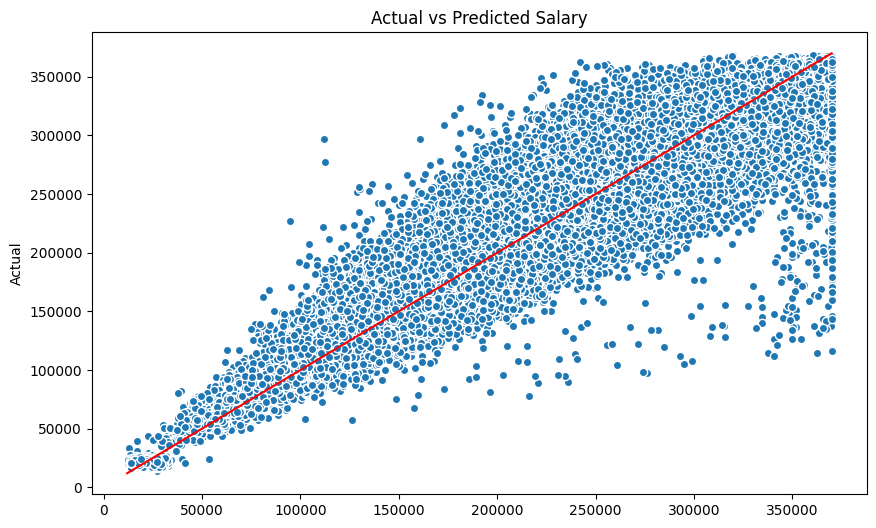

In [80]:
# Visualizing The Regression Results: Predicted vs Actual Visualtion
# FROM: https://codesignal.com/learn/courses/regression-analysis-to-model-diamond-prices/lessons/visualizing-actual-vs-predicted-prices-in-regression-models

plt.figure(figsize=(10, 6))

# Add Scatter For Visuale The Points
plt.scatter(y_test, y_pred, edgecolors="w")
plt.ylabel("Prediction")
plt.ylabel("Actual")
plt.title('Actual vs Predicted Salary')

# Visuale The Line For The Prefect Prediction
limits = [y_test.min(), y_test.max()]
plt.plot(limits, limits, color="red", linestyle="-", ) # draw line with coordinate (x1, y1) and (x2, y2)

In [81]:
# Get Mean Absolute Error (MAE)
mae_val = sum(abs(y_pred_real_df["salary"] - y_pred_real_df["salary_pred"])) / y_pred_real_df["salary"].size
print(mae_val)
mae(y_pred=y_pred_real_df["salary_pred"], y_true=y_pred_real_df["salary"])

22877.166743950394


22877.166743950398

In [82]:
# Root Mean Squared Error (RMSE)
rmse_val = sqrt(sum(pow(y_pred_real_df["salary"] - y_pred_real_df["salary_pred"], 2)) / y_test.count())
print(rmse_val)
rmse(y_pred=y_pred_real_df["salary_pred"], y_true=y_pred_real_df["salary"])

31990.077325680417


31990.077325680417

In [83]:
# Get R²
mean_y_test_set = y_test.mean()
r_2_val = 1 - (sum(pow(y_pred_real_df["salary"] - y_pred_real_df["salary_pred"], 2)) / sum(pow(y_pred_real_df["salary"] - mean_y_test_set, 2)))
print(r_2_val)

r_2(y_pred=y_pred_real_df["salary_pred"], y_true=y_pred_real_df["salary"])

0.8611404870561367


0.8611404870561365

In [84]:
# Get Adjustement R²


{'years_of_experience': np.float64(0.2167057967593244), 'education_level': np.float64(0.12216866197619765), 'gender': np.float64(0.012500712700289554), 'company_size': np.float64(0.07687043995622261), 'field_Business': np.float64(0.0008724647493545882), 'field_Design': np.float64(0.0008927933925351199), 'field_Finance': np.float64(0.0010257326942468667), 'field_Human Resources': np.float64(0.010528821230077319), 'field_Marketing': np.float64(0.008799714795980762), 'field_Operations': np.float64(0.001922356764279296), 'field_Technology': np.float64(0.07843910804470336), 'employment_type_freelance': np.float64(0.004740664783799382), 'employment_type_full_time': np.float64(0.005196387445895593), 'employment_type_internship': np.float64(0.02446215760433938), 'employment_type_part_time': np.float64(0.005374566393502052), 'employment_type_work_from_home': np.float64(0.005149443206138935), 'city_Amsterdam': np.float64(0.0010682096330036693), 'city_Auckland': np.float64(0.0029341674252220426),

<BarContainer object of 71 artists>

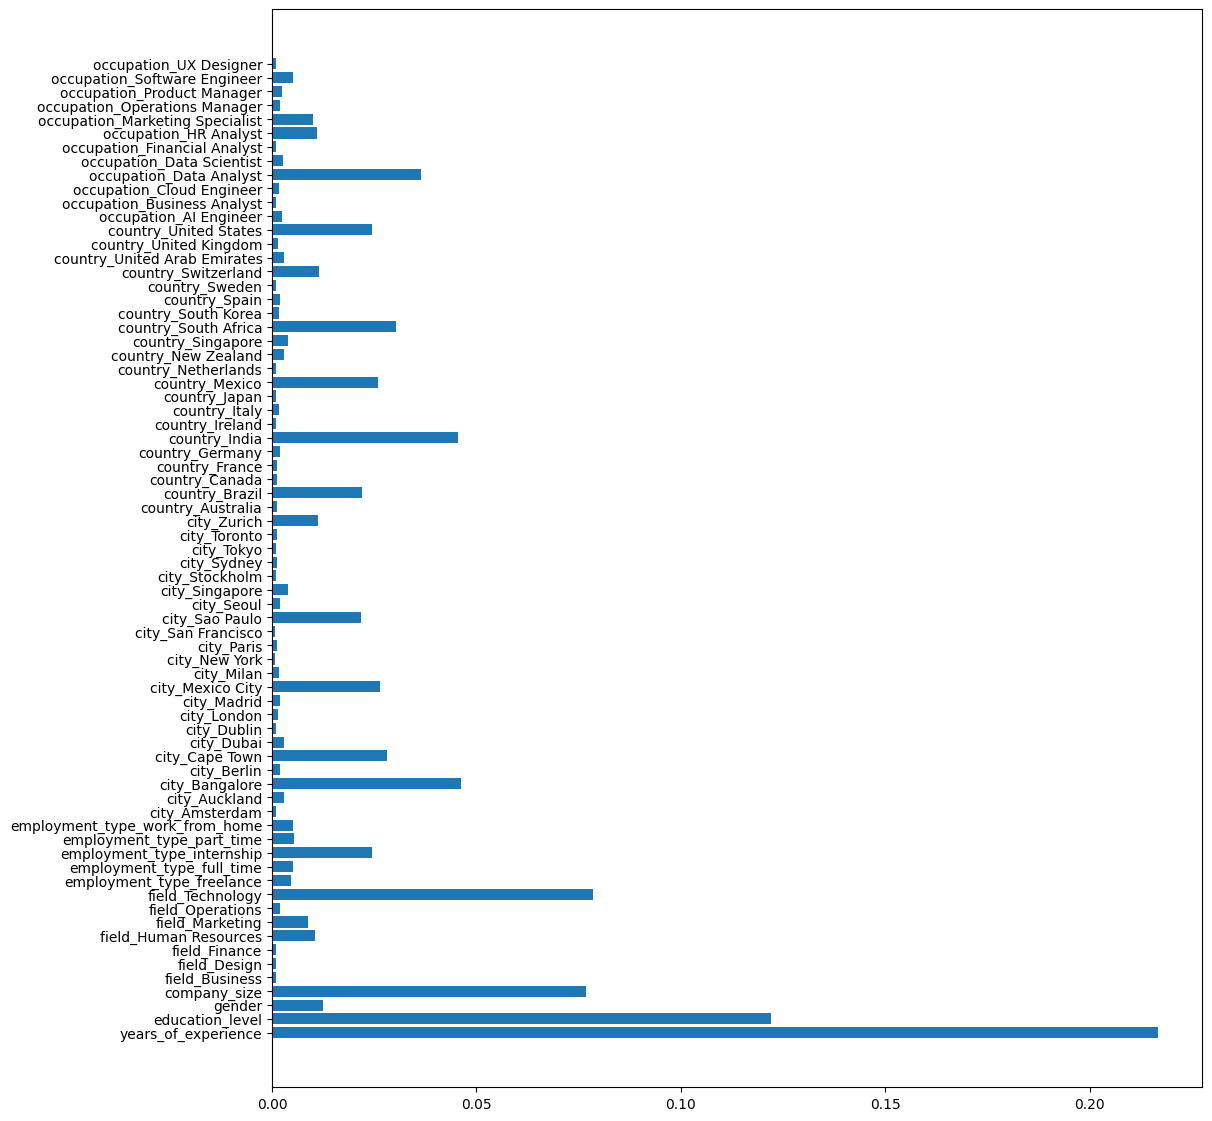

In [85]:
# Features Importance
features_names = model.feature_names_in_
features_importances = model.feature_importances_
dic_f = {}
for i in range(len(features_names)):
    dic_f[features_names[i]] = features_importances[i]
print(dic_f)

# Visuale The Feature Importance
plt.figure(figsize=(12, 14))
plt.barh(features_names, features_importances)